# Multi-Output ANN: Results Viewer

This notebook **displays results** from the multi-output ANN trained by `run_training.py`.
It loads saved model weights, scaler, and metrics from disk — no training is performed here.

**Artifacts expected in:**
- `models/multi_output/stellar_multi_output_ann_best.pth`
- `models/multi_output/scaler_multi_output.pkl`
- `results/multi_output/test_metrics.json`
- `results/multi_output/*.png`

**Baseline to beat**: Residual ANN (single-output log g) — R² = 0.519, RMSE = 0.199 dex.

## 1. Imports & Configuration

In [46]:
import pandas as pd

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_context("talk")

DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cpu


## 2. Paths & Directories

In [48]:
PROJECT_ROOT = Path("C:/git_repo/cool-dwarf_stellar_parameter_inference_from_survey_data")
DATA_PATH    = PROJECT_ROOT / "data" / "logg_final_df" / "cool_dwarf_catalog_FGKM_consolidated.csv"
RESULTS_DIR  = PROJECT_ROOT / "results" / "multi_output"
MODELS_DIR   = PROJECT_ROOT / "models"  / "multi_output"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data:    {DATA_PATH}")
print(f"Results: {RESULTS_DIR}")
print(f"Models:  {MODELS_DIR}")

Data:    C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\logg_final_df\cool_dwarf_catalog_FGKM_consolidated.csv
Results: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\multi_output
Models:  C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\multi_output


## 3. Data Loading & Inspection

In [49]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nSpectral type distribution:")
print(df["spectral_type_group"].value_counts().sort_index())
print(f"\nTeff  range: {df['teff'].min():.1f} \u2013 {df['teff'].max():.1f} K")
print(f"log g range: {df['logg'].min():.2f} \u2013 {df['logg'].max():.2f} dex")
df[["teff", "logg", "spectral_type_group"]].describe()

Dataset shape: (904427, 197)

Spectral type distribution:
spectral_type_group
F    274831
G    578786
K     18889
M     31921
Name: count, dtype: int64

Teff  range: 3114.1 – 8088.0 K
log g range: 3.50 – 5.02 dex


,teff,logg
count,904427.000000,904427.000000
mean,5560.209702,4.319136
std,738.713192,0.287698
min,3114.080000,3.500000
25%,5159.690000,4.122000
50%,5638.220000,4.306000
75%,6014.010000,4.574000
max,8088.000000,5.021000


## 4. Feature & Target Definition

171 photometric color indices. Two targets:
- **col 0**: `log10(Teff)` — consistent with single-output Teff model, compresses dynamic range
- **col 1**: `log g` (raw dex)

In [50]:
sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP',
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H',
    'A_KS', 'A_W1', 'A_W2'
]

FEATURE_COLS = [
    f'COLOR_{sorted_mags[i]}_{sorted_mags[j]}'
    for i in range(len(sorted_mags))
    for j in range(i + 1, len(sorted_mags))
]

X = df[FEATURE_COLS].values.astype(np.float32)

# Targets: (N, 2)
log10_teff = np.log10(df["teff"].values).astype(np.float32)
logg       = df["logg"].values.astype(np.float32)
y          = np.column_stack([log10_teff, logg]).astype(np.float32)

spectral_types = df["spectral_type_group"].values

assert not np.any(np.isnan(X))  and not np.any(np.isinf(X)),  "NaN/Inf in features!"
assert not np.any(np.isnan(y))  and not np.any(np.isinf(y)),  "NaN/Inf in targets!"

print(f"Features:       {X.shape[1]} color indices")
print(f"Targets shape:  {y.shape}  (col 0 = log10(Teff), col 1 = log g)")
print(f"log10(Teff) range: [{y[:,0].min():.4f}, {y[:,0].max():.4f}]")
print(f"log g range:       [{y[:,1].min():.4f}, {y[:,1].max():.4f}]")

Features:       171 color indices
Targets shape:  (904427, 2)  (col 0 = log10(Teff), col 1 = log g)
log10(Teff) range: [3.4933, 3.9078]
log g range:       [3.5000, 5.0210]


## 5. Train / Validation / Test Split (70 / 15 / 15)

In [51]:
X_train, X_temp, y_train, y_temp, st_train, st_temp = train_test_split(
    X, y, spectral_types,
    test_size=0.30, random_state=SEED, stratify=spectral_types,
)
X_val, X_test, y_val, y_test, st_val, st_test = train_test_split(
    X_temp, y_temp, st_temp,
    test_size=0.50, random_state=SEED, stratify=st_temp,
)

# Recover raw Teff (K) from log10 for Teff-based augmentation binning
teff_train_raw = (10.0 ** y_train[:, 0]).astype(np.float64)

print(f"{'Split':<12} {'Samples':>10}  {'% of total':>10}")
print("-" * 36)
total = len(y)
for name, arr in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(arr):>10,}  {100*len(arr)/total:>9.1f}%")

print(f"\nSpectral type proportions (%):")
print(f"{'Type':<6} {'Full':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for stype in ["F", "G", "K", "M"]:
    full_pct  = 100 * np.sum(spectral_types == stype) / len(spectral_types)
    train_pct = 100 * np.sum(st_train == stype) / len(st_train)
    val_pct   = 100 * np.sum(st_val   == stype) / len(st_val)
    test_pct  = 100 * np.sum(st_test  == stype) / len(st_test)
    print(f"{stype:<6} {full_pct:>7.1f}% {train_pct:>7.1f}% {val_pct:>7.1f}% {test_pct:>7.1f}%")

Split           Samples  % of total
------------------------------------
Train           633,098       70.0%
Validation      135,664       15.0%
Test            135,665       15.0%

Spectral type proportions (%):
Type       Full    Train      Val     Test
----------------------------------------
F         30.4%    30.4%    30.4%    30.4%
G         64.0%    64.0%    64.0%    64.0%
K          2.1%     2.1%     2.1%     2.1%
M          3.5%     3.5%     3.5%     3.5%


## 6. Data Augmentation

Augmentation (Teff-binned, error-aware oversampling) is performed during training in `run_training.py`.
Skipped here — the fitted scaler is loaded directly from disk in the next section.

In [52]:
# Augmentation is handled in run_training.py — not needed here.
print("Augmentation step skipped (results-viewer mode).")

Augmentation step skipped (results-viewer mode).


## 7. Load Saved Scaler

Load the `StandardScaler` that was fitted on original (un-augmented) training data by `run_training.py`.
Apply it to the test set only.

In [53]:
scaler_path = MODELS_DIR / "scaler_multi_output.pkl"
scaler = joblib.load(scaler_path)
print(f"Loaded scaler from: {scaler_path}")

# Only the test set needs scaling for evaluation
X_test_scaled = scaler.transform(X_test).astype(np.float32)
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Loaded scaler from: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\multi_output\scaler_multi_output.pkl


X_test_scaled shape: (135665, 171)


## 8. PyTorch Test DataLoader

Only the test set is wrapped in a DataLoader — train/val are not needed for evaluation.

In [54]:
class StellarMultiDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets,  dtype=torch.float32)
    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 1024
test_dataset = StellarMultiDataset(X_test_scaled, y_test)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0)
print(f"Test set: {len(test_dataset):,} samples  ({len(test_loader)} batches)")

Test set: 135,665 samples  (67 batches)


## 9. Model Architecture — Shared Backbone + Dual Heads

```
Input (171)
    └── ResBlock(171→256)
            └── ResBlock(256→128)
                    ├── Teff head: Linear(128→64) → BN → ReLU → Dropout(0.10) → Linear(64→1)
                    └── log g head: Linear(128→64) → BN → ReLU → Dropout(0.10) → Linear(64→1)
```

Splitting after the second ResBlock maximises shared representation while giving each head enough capacity to specialise.

In [55]:
class ResBlock(nn.Module):
    """Residual block with optional dimension projection for the skip connection."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + self.skip(x))


class StellarMultiOutputNet(nn.Module):
    """
    Shared residual backbone with two task-specific output heads.
    Output tensor shape: (B, 2)  — col 0: log10(Teff), col 1: log g
    """
    def __init__(self, input_dim: int, dropout: float = 0.15):
        super().__init__()
        self.backbone = nn.Sequential(
            ResBlock(input_dim, 256, dropout),
            ResBlock(256, 128, dropout),
        )
        self.teff_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1),
        )
        self.logg_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        shared = self.backbone(x)
        return torch.cat([self.teff_head(shared), self.logg_head(shared)], dim=1)


model = StellarMultiOutputNet(input_dim=len(FEATURE_COLS)).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Input dim: {len(FEATURE_COLS)} | Outputs: 2 (log10 Teff, log g)")

StellarMultiOutputNet(
  (backbone): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Linear(in_features=171, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Linear(in_features=171, out_features=256, bias=True)
      (relu): ReLU()
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_s

## 10. Loss Function — Homoscedastic Uncertainty Weighting

From Kendall & Gal (2017). For each task $t$:

$$\mathcal{L}_t = e^{-\log s_t} \cdot \mathrm{MSE}_t + \log s_t$$

where $\log s_t$ is a learnable log-variance parameter. When $\mathrm{MSE}_t$ is large the model learns to upweight uncertainty (increase $\log s_t$), reducing the effective weight on that task. This removes the need for manual loss weighting.

In [56]:
class HomoscedasticUncertaintyLoss(nn.Module):
    """
    Multi-task regression loss with learnable task uncertainties.
    L = exp(-log_s_teff)*MSE_teff + log_s_teff
      + exp(-log_s_logg)*MSE_logg + log_s_logg
    """
    def __init__(self):
        super().__init__()
        self.log_s_teff = nn.Parameter(torch.zeros(1))
        self.log_s_logg = nn.Parameter(torch.zeros(1))

    def forward(self, pred: torch.Tensor, target: torch.Tensor):
        """
        pred, target: (B, 2) — col 0: log10(Teff), col 1: log g
        Returns: total_loss, mse_teff (scalar), mse_logg (scalar)
        """
        mse_teff = F.mse_loss(pred[:, 0], target[:, 0])
        mse_logg = F.mse_loss(pred[:, 1], target[:, 1])
        loss = (
            torch.exp(-self.log_s_teff) * mse_teff + self.log_s_teff
            + torch.exp(-self.log_s_logg) * mse_logg + self.log_s_logg
        )
        return loss, mse_teff.detach().item(), mse_logg.detach().item()


criterion = HomoscedasticUncertaintyLoss().to(DEVICE)
print("Initial task weights (exp(-log_s)):")
print(f"  Teff:  log_s = {criterion.log_s_teff.item():.4f}  weight = {torch.exp(-criterion.log_s_teff).item():.4f}")
print(f"  log g: log_s = {criterion.log_s_logg.item():.4f}  weight = {torch.exp(-criterion.log_s_logg).item():.4f}")

Initial task weights (exp(-log_s)):
  Teff:  log_s = 0.0000  weight = 1.0000
  log g: log_s = 0.0000  weight = 1.0000


## 11. Load Saved Model

Load the best model checkpoint (weights + learned task uncertainties) saved by `run_training.py`.

In [57]:
MODEL_PATH = MODELS_DIR / "stellar_multi_output_ann_best.pth"
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
criterion.load_state_dict(checkpoint["criterion_state_dict"])
model.eval()

print(f"Loaded model from: {MODEL_PATH}")
print(f"  Best epoch:    {checkpoint['best_epoch']}")
print(f"  Best val loss: {checkpoint['best_val_loss']:.6f}")
print(f"\nLearned task weights:")
print(f"  Teff  log_s = {criterion.log_s_teff.item():.4f}  weight = {torch.exp(-criterion.log_s_teff).item():.4f}")
print(f"  log g log_s = {criterion.log_s_logg.item():.4f}  weight = {torch.exp(-criterion.log_s_logg).item():.4f}")

Loaded model from: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\multi_output\stellar_multi_output_ann_best.pth
  Best epoch:    64
  Best val loss: -10.176920

Learned task weights:
  Teff  log_s = -8.5566  weight = 5200.8169
  log g log_s = -3.2869  weight = 26.7596


## 12. Inference Helper

In [58]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Run inference on a DataLoader; return average loss and per-task MSE."""
    model.eval()
    total_loss = total_mse_teff = total_mse_logg = 0.0
    n = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        preds = model(X_b)
        loss, mse_t, mse_l = criterion(preds, y_b)
        bs = X_b.size(0)
        total_loss     += loss.item() * bs
        total_mse_teff += mse_t       * bs
        total_mse_logg += mse_l       * bs
        n += bs
    return total_loss / n, total_mse_teff / n, total_mse_logg / n

## 13. Training Summary

In [59]:
# Training was performed externally by run_training.py.
# Training diagnostics (loss curves, task weights, LR) are displayed in the next cell.
print("Training skipped — model loaded from disk.")

Training skipped — model loaded from disk.


## 14. Training Diagnostics

Loss curves, per-task MSE, learned task weights, and LR schedule — saved by `run_training.py`.

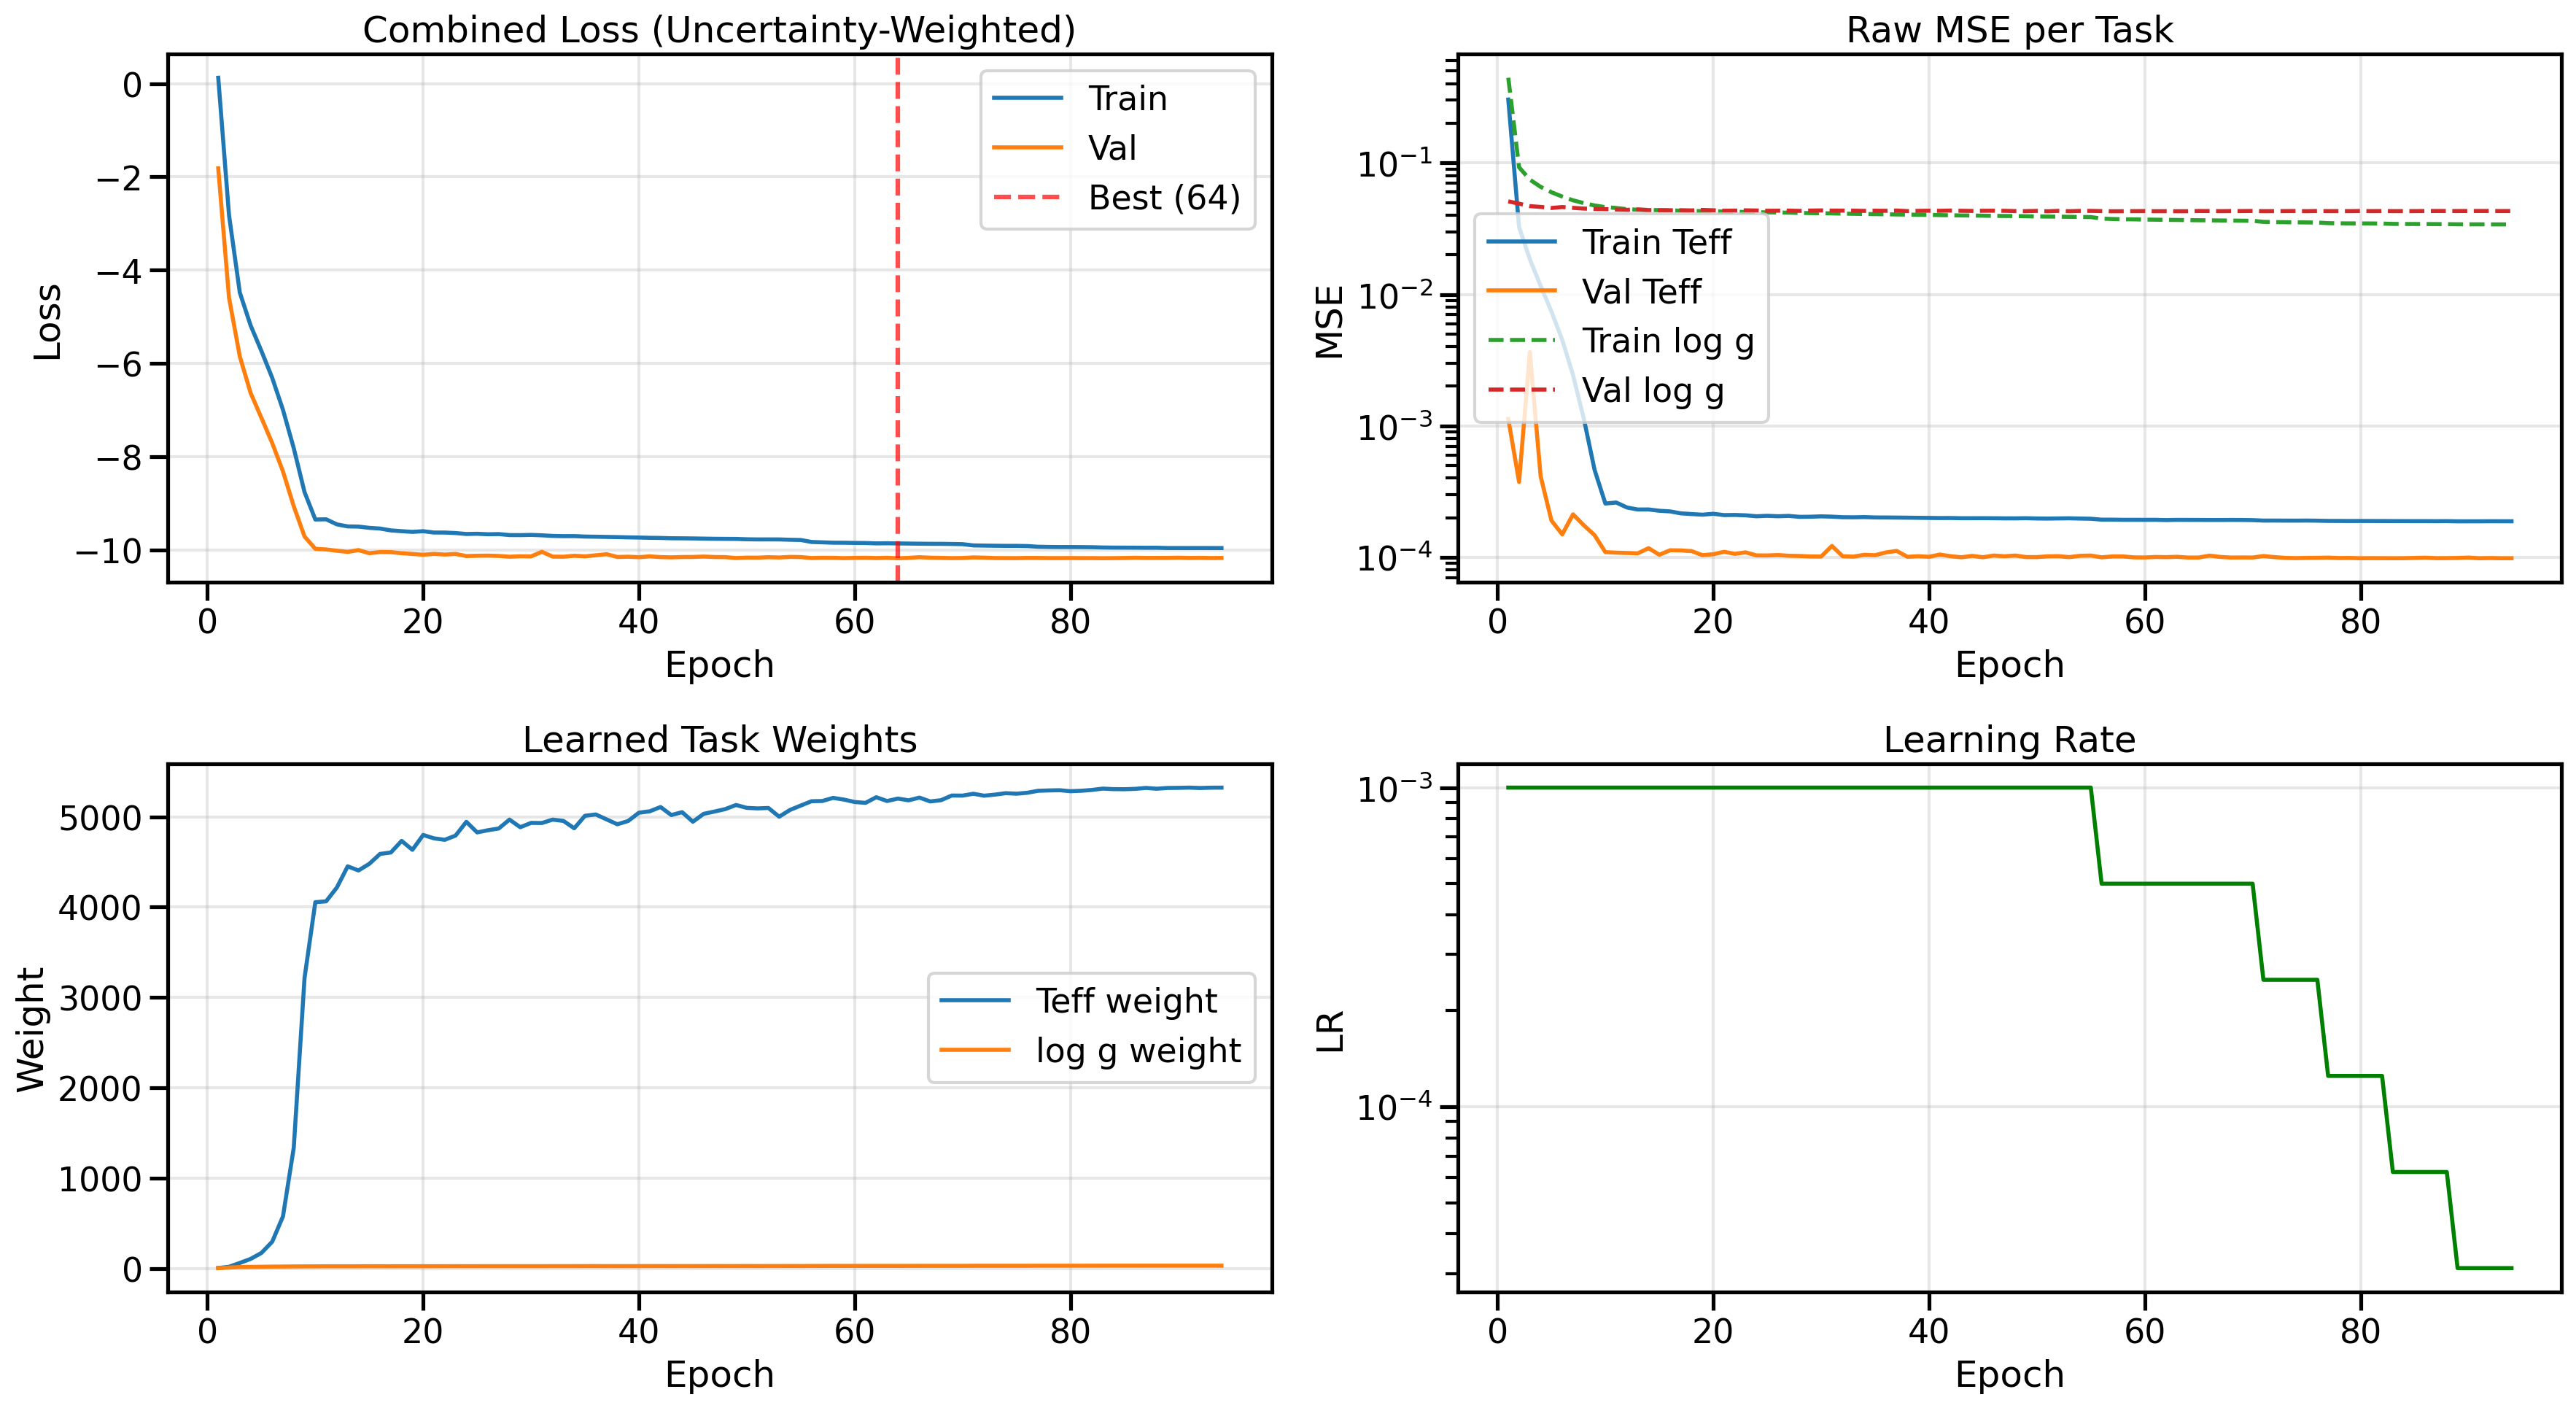

In [60]:
from IPython.display import Image as IPyImage, display as ipy_display

diag_path = RESULTS_DIR / "training_diagnostics.png"
if diag_path.exists():
    ipy_display(IPyImage(filename=str(diag_path), width=1200))
else:
    print(f"File not found: {diag_path}")
    print("Run run_training.py first to generate this file.")

## 15. Test Set Evaluation

In [62]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(DEVICE))
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_b.numpy())

preds_arr   = np.concatenate(all_preds)    # (N_test, 2)
targets_arr = np.concatenate(all_targets)  # (N_test, 2)

# ── Teff ──────────────────────────────────────────────────────────────────────
log10_teff_pred = preds_arr[:, 0]
log10_teff_true = targets_arr[:, 0]
teff_pred_K     = 10.0 ** log10_teff_pred
teff_true_K     = 10.0 ** log10_teff_true

rmse_teff     = np.sqrt(mean_squared_error(teff_true_K, teff_pred_K))
mae_teff      = mean_absolute_error(teff_true_K, teff_pred_K)
r2_teff       = r2_score(teff_true_K, teff_pred_K)
r2_log10_teff = r2_score(log10_teff_true, log10_teff_pred)

# ── log g ─────────────────────────────────────────────────────────────────────
logg_pred = preds_arr[:, 1]
logg_true = targets_arr[:, 1]

rmse_logg = np.sqrt(mean_squared_error(logg_true, logg_pred))
mae_logg  = mean_absolute_error(logg_true, logg_pred)
r2_logg   = r2_score(logg_true, logg_pred)

print("=" * 60)
print("  TEST SET RESULTS \u2014 Multi-Output ANN")
print("=" * 60)
print(f"\n  Teff:")
print(f"    RMSE:        {rmse_teff:>8.2f} K")
print(f"    MAE:         {mae_teff:>8.2f} K")
print(f"    R\u00b2 (K):      {r2_teff:>8.5f}")
print(f"    R\u00b2 (log10):  {r2_log10_teff:>8.5f}")
print(f"\n  log g:")
print(f"    RMSE:        {rmse_logg:>8.4f} dex")
print(f"    MAE:         {mae_logg:>8.4f} dex")
print(f"    R\u00b2:          {r2_logg:>8.5f}")

print(f"\n{'_' * 60}")
print("  Per-Spectral-Type Breakdown (for physical interpretation)")
print(f"{'_' * 60}")
#print(f"  {'Type':<4} {'N':>8}  {'Teff R\u00b2':>9}  {'log g R\u00b2':>10}  {'log g RMSE':>11}")
print(f"  {'----':<4} {'----':>8}  {'---------':>9}  {'----------':>10}  {'-----------':>11}")

per_type_metrics = {}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    if mask.sum() == 0:
        continue
    teff_r2   = r2_score(teff_true_K[mask], teff_pred_K[mask])
    logg_r2   = r2_score(logg_true[mask],   logg_pred[mask])
    logg_rmse = np.sqrt(mean_squared_error(logg_true[mask], logg_pred[mask]))
    per_type_metrics[stype] = {"teff_r2": teff_r2, "logg_r2": logg_r2, "logg_rmse": logg_rmse}
    print(f"  {stype:<4} {mask.sum():>8,}  {teff_r2:>9.4f}  {logg_r2:>10.4f}  {logg_rmse:>11.4f}")

  TEST SET RESULTS — Multi-Output ANN

  Teff:
    RMSE:          132.03 K
    MAE:            95.89 K
    R² (K):       0.96806
    R² (log10):   0.97307

  log g:
    RMSE:          0.2067 dex
    MAE:           0.1409 dex
    R²:           0.48343

____________________________________________________________
  Per-Spectral-Type Breakdown (for physical interpretation)
____________________________________________________________
  ----     ----  ---------  ----------  -----------
  F      41,225     0.8656      0.1899       0.1497
  G      86,818     0.9490      0.3816       0.2346
  K       2,834     0.9320     -0.6107       0.1612
  M       4,788     0.9286      0.3564       0.0699


## 16. One-to-One Plots

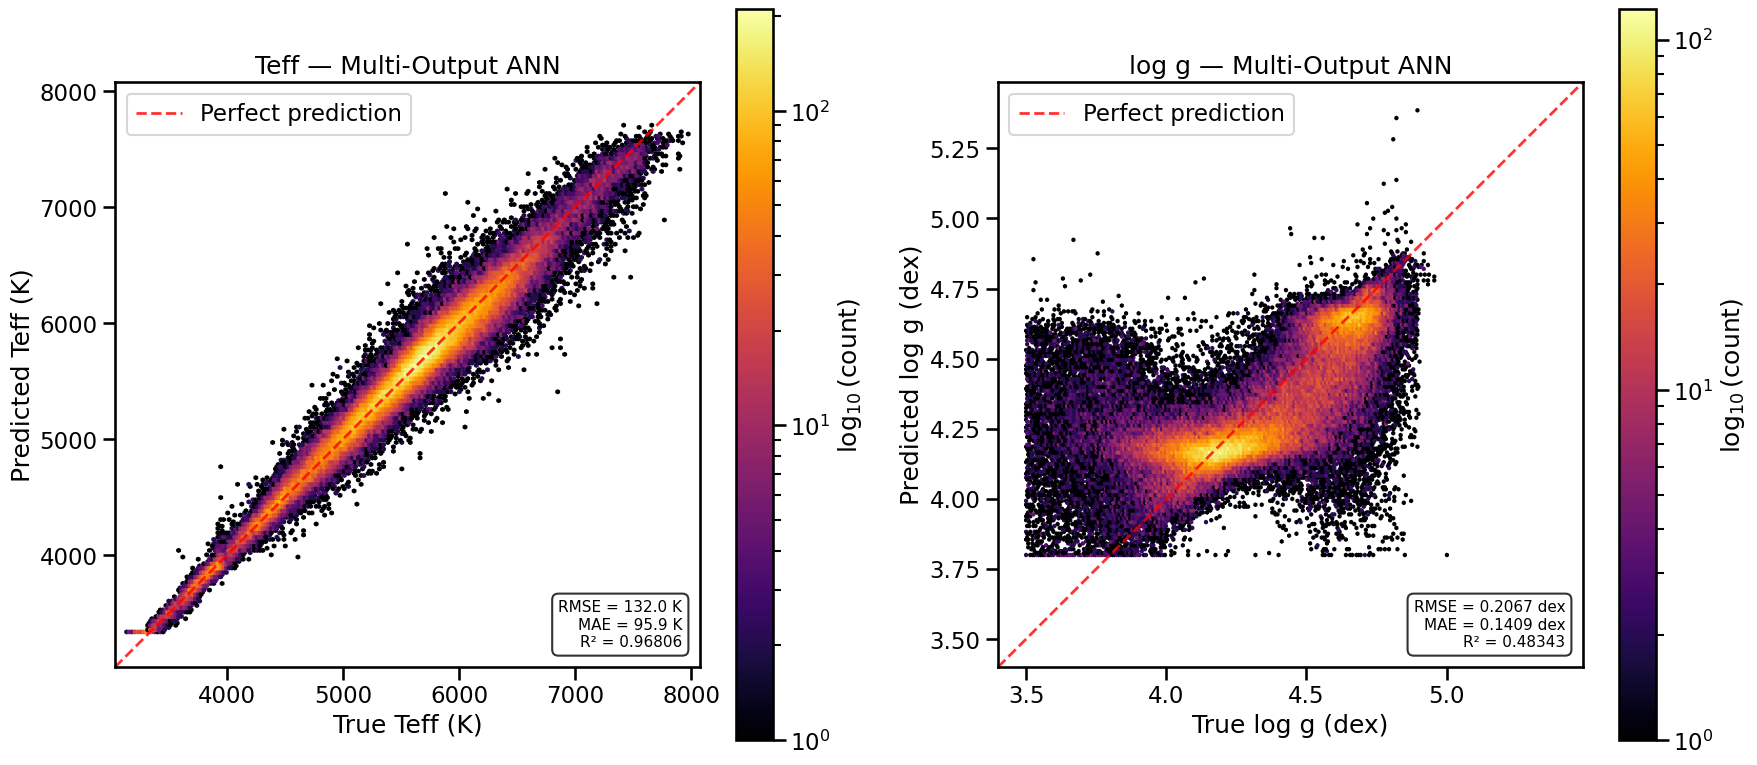

Saved: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\multi_output\one_to_one_plots.png


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Teff
ax = axes[0]
hb = ax.hexbin(teff_true_K, teff_pred_K, gridsize=200, cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, ax=ax, label=r"$\log_{10}$(count)")
lims_t = [min(teff_true_K.min(), teff_pred_K.min()) - 100,
          max(teff_true_K.max(), teff_pred_K.max()) + 100]
ax.plot(lims_t, lims_t, "r--", lw=2, alpha=0.8, label="Perfect prediction")
ax.set_xlim(lims_t); ax.set_ylim(lims_t)
ax.set_xlabel("True Teff (K)"); ax.set_ylabel("Predicted Teff (K)")
ax.set_title("Teff \u2014 Multi-Output ANN")
ax.set_aspect("equal"); ax.legend(loc="upper left")
ax.text(0.97, 0.03,
        f"RMSE = {rmse_teff:.1f} K\nMAE = {mae_teff:.1f} K\nR\u00b2 = {r2_teff:.5f}",
        transform=ax.transAxes, fontsize=11, va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))

# log g
ax = axes[1]
hb = ax.hexbin(logg_true, logg_pred, gridsize=200, cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, ax=ax, label=r"$\log_{10}$(count)")
lims_g = [min(logg_true.min(), logg_pred.min()) - 0.1,
          max(logg_true.max(), logg_pred.max()) + 0.1]
ax.plot(lims_g, lims_g, "r--", lw=2, alpha=0.8, label="Perfect prediction")
ax.set_xlim(lims_g); ax.set_ylim(lims_g)
ax.set_xlabel("True log g (dex)"); ax.set_ylabel("Predicted log g (dex)")
ax.set_title("log g \u2014 Multi-Output ANN")
ax.set_aspect("equal"); ax.legend(loc="upper left")
ax.text(0.97, 0.03,
        f"RMSE = {rmse_logg:.4f} dex\nMAE = {mae_logg:.4f} dex\nR\u00b2 = {r2_logg:.5f}",
        transform=ax.transAxes, fontsize=11, va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "one_to_one_plots.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'one_to_one_plots.png'}")

## 17. Residual Plots

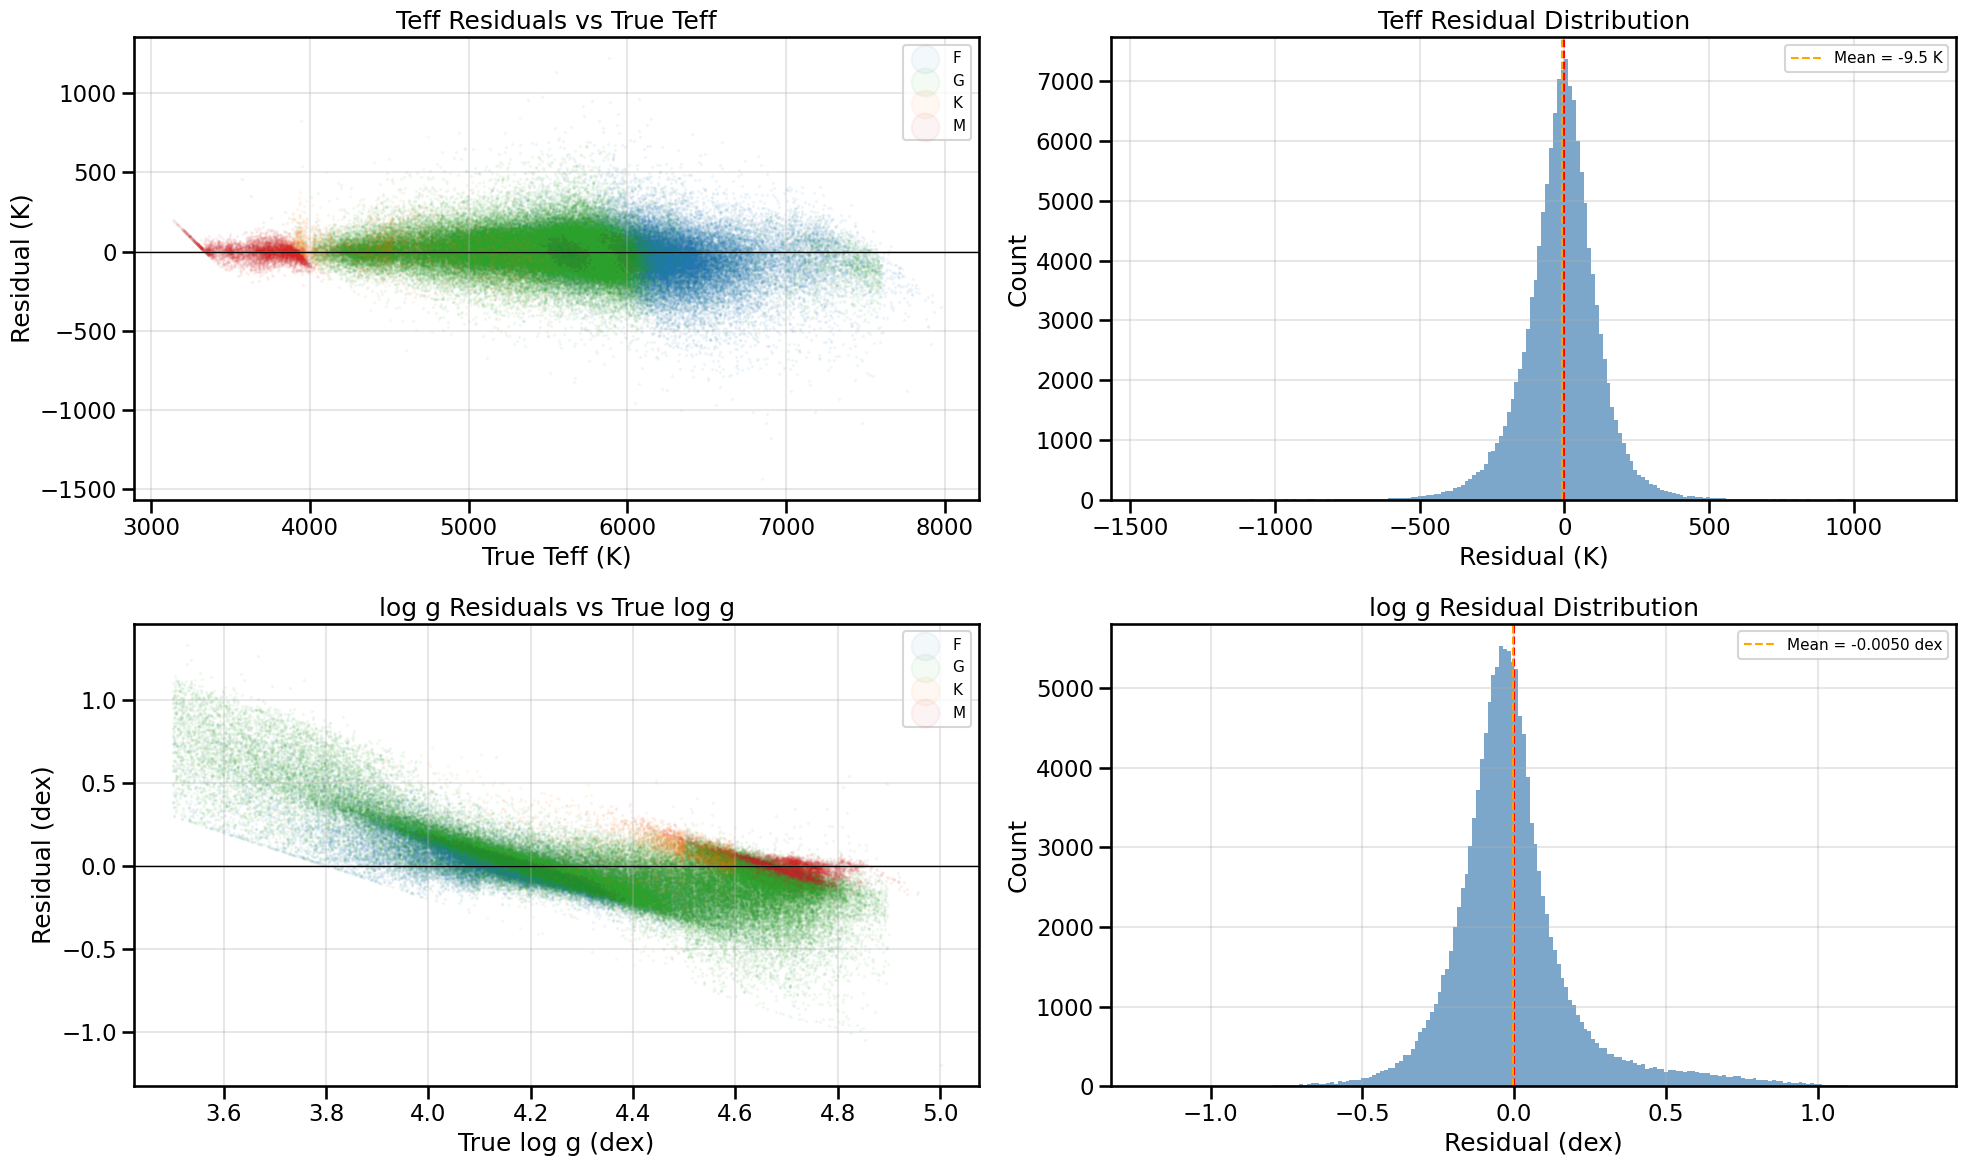

Saved: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\multi_output\residual_plots.png


In [64]:
residuals_teff = teff_pred_K - teff_true_K
residuals_logg = logg_pred   - logg_true

colors_map = {"F": "#1f77b4", "G": "#2ca02c", "K": "#ff7f0e", "M": "#d62728"}

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Teff residuals vs true
ax = axes[0, 0]
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    ax.scatter(teff_true_K[mask], residuals_teff[mask],
               alpha=0.05, s=1, color=colors_map[stype], label=stype, rasterized=True)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("True Teff (K)"); ax.set_ylabel("Residual (K)")
ax.set_title("Teff Residuals vs True Teff")
ax.legend(markerscale=20, fontsize=11); ax.grid(True, alpha=0.3)

# Teff residual histogram
ax = axes[0, 1]
ax.hist(residuals_teff, bins=200, edgecolor="none", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", ls="--", lw=1.5)
ax.axvline(np.mean(residuals_teff), color="orange", ls="--", lw=1.5,
           label=f"Mean = {np.mean(residuals_teff):.1f} K")
ax.set_xlabel("Residual (K)"); ax.set_ylabel("Count")
ax.set_title("Teff Residual Distribution")
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

# log g residuals vs true
ax = axes[1, 0]
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    ax.scatter(logg_true[mask], residuals_logg[mask],
               alpha=0.05, s=1, color=colors_map[stype], label=stype, rasterized=True)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("True log g (dex)"); ax.set_ylabel("Residual (dex)")
ax.set_title("log g Residuals vs True log g")
ax.legend(markerscale=20, fontsize=11); ax.grid(True, alpha=0.3)

# log g residual histogram
ax = axes[1, 1]
ax.hist(residuals_logg, bins=200, edgecolor="none", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", ls="--", lw=1.5)
ax.axvline(np.mean(residuals_logg), color="orange", ls="--", lw=1.5,
           label=f"Mean = {np.mean(residuals_logg):.4f} dex")
ax.set_xlabel("Residual (dex)"); ax.set_ylabel("Count")
ax.set_title("log g Residual Distribution")
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "residual_plots.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'residual_plots.png'}")

## 18. Saved Metrics

Load and display the test metrics JSON saved by `run_training.py`.

In [65]:
import json

metrics_path = RESULTS_DIR / "test_metrics.json"
with open(metrics_path) as f:
    metrics = json.load(f)

print(f"Loaded metrics from: {metrics_path}")
print(json.dumps(metrics, indent=2))

Loaded metrics from: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\multi_output\test_metrics.json
{
  "model": "multi_output_ann",
  "teff": {
    "rmse_K": 132.031,
    "mae_K": 95.889,
    "r2_K": 0.96806,
    "r2_log10": 0.973072
  },
  "logg": {
    "rmse_dex": 0.206744,
    "mae_dex": 0.140882,
    "r2_score": 0.483428
  },
  "learned_weights": {
    "teff_weight": 5200.816996,
    "logg_weight": 26.759609
  },
  "training": {
    "best_epoch": 64,
    "total_epochs_run": 94,
    "n_train_augmented": 2163707,
    "n_val": 135664,
    "n_test": 135665,
    "n_features": 171,
    "augmentation_bin_width_K": 150.0
  },
  "per_type": {
    "F": {
      "teff_r2": 0.865557,
      "logg_r2": 0.189942,
      "logg_rmse": 0.149738
    },
    "G": {
      "teff_r2": 0.948978,
      "logg_r2": 0.381572,
      "logg_rmse": 0.23458
    },
    "K": {
      "teff_r2": 0.931983,
      "logg_r2": -0.610722,
      "logg_rmse": 0.16116
    },
    "M": {
      "teff_r2"

## 19. Comparison with Baselines

In [68]:
baseline_logg = {
    "4-layer ANN, single-output":  {"r2": 0.487838, "rmse": 0.20586},
    "Residual ANN, single-output": {"r2": 0.51924,  "rmse": 0.19940},
}
baseline_teff = {
    "4-layer ANN, single-output":  {"r2": 0.965, "rmse": 144.0},
}

print("=" * 68)
print("  COMPARISON \u2014 log g")
print("=" * 68)
#print(f"  {'Model':<38} {'R\u00b2':>10}  {'RMSE (dex)':>12}")
print(f"  {'-'*38} {'-'*10}  {'-'*12}")
for name, m in baseline_logg.items():
    print(f"  {name:<38} {m['r2']:>10.5f}  {m['rmse']:>12.5f}")
delta_r2   = r2_logg   - 0.51924
delta_rmse = rmse_logg - 0.19940
flag = '\u2191 IMPROVED' if r2_logg > 0.51924 else '\u2193 REGRESSED'
print(f"  {'Multi-Output ANN (this)':<38} {r2_logg:>10.5f}  {rmse_logg:>12.5f}  "
      f"({delta_r2:+.5f} R\u00b2, {delta_rmse:+.5f} RMSE)  {flag}")

print(f"\n{'=' * 68}")
print("  COMPARISON \u2014 Teff")
print(f"{'=' * 68}")
#print(f"  {'Model':<38} {'R\u00b2':>10}  {'RMSE (K)':>10}")
print(f"  {'-'*38} {'-'*10}  {'-'*10}")
for name, m in baseline_teff.items():
    print(f"  {name:<38} {m['r2']:>10.5f}  {m['rmse']:>10.1f}")
print(f"  {'Multi-Output ANN (this)':<38} {r2_teff:>10.5f}  {rmse_teff:>10.1f}")

print(f"\n  Final learned task weights:")
print(f"    Teff  weight = {float(np.exp(-criterion.log_s_teff.item())):.4f}")
print(f"    log g weight = {float(np.exp(-criterion.log_s_logg.item())):.4f}")

  COMPARISON — log g
  -------------------------------------- ----------  ------------
  4-layer ANN, single-output                0.48784       0.20586
  Residual ANN, single-output               0.51924       0.19940
  Multi-Output ANN (this)                   0.48343       0.20674  (-0.03581 R², +0.00734 RMSE)  ↓ REGRESSED

  COMPARISON — Teff
  -------------------------------------- ----------  ----------
  4-layer ANN, single-output                0.96500       144.0
  Multi-Output ANN (this)                   0.96806       132.0

  Final learned task weights:
    Teff  weight = 5200.8170
    log g weight = 26.7596
